  Manufacturer    Model  Sales_in_thousands  __year_resale_value Vehicle_type  \
0        Acura  Integra              16.919               16.360    Passenger   
1        Acura       TL              39.384               19.875    Passenger   
2        Acura       CL              14.114               18.225    Passenger   
3        Acura       RL               8.588               29.725    Passenger   
4         Audi       A4              20.397               22.255    Passenger   

   Price_in_thousands  Engine_size  Horsepower  Wheelbase  Width  Length  \
0               21.50          1.8       140.0      101.2   67.3   172.4   
1               28.40          3.2       225.0      108.1   70.3   192.9   
2                 NaN          3.2       225.0      106.9   70.6   192.0   
3               42.00          3.5       210.0      114.6   71.4   196.6   
4               23.99          1.8       150.0      102.6   68.2   178.0   

   Curb_weight  Fuel_capacity  Fuel_efficiency Latest_La

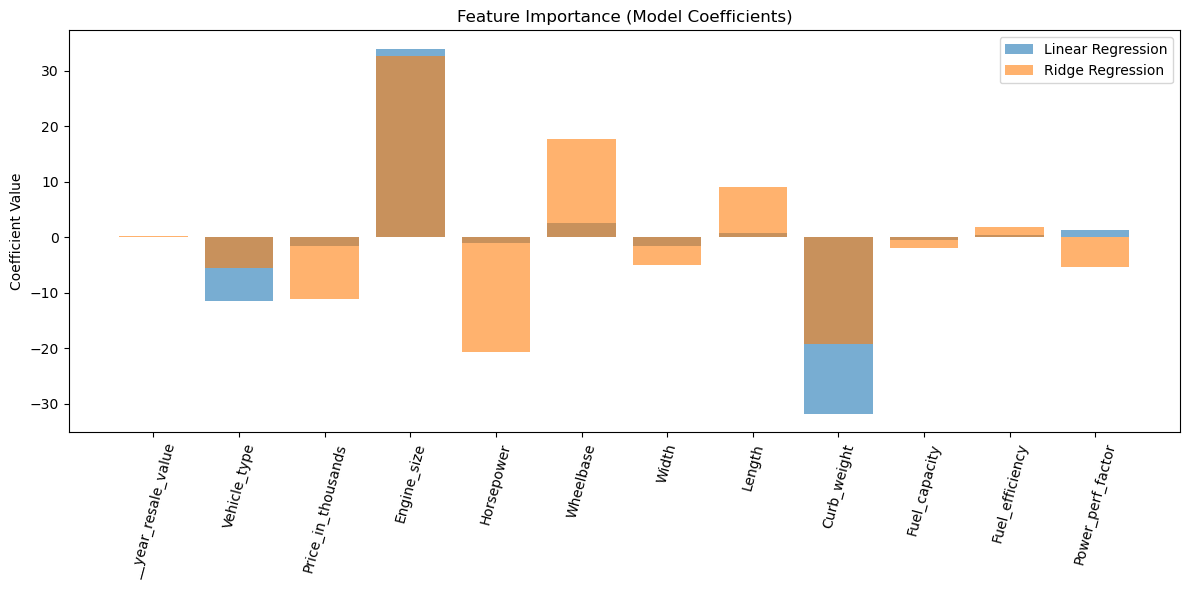

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
file_path = "Car_sales.csv"
df = pd.read_csv(file_path)

# Show first rows
print(df.head())
print(df.info())
print(df.isnull().sum())

# Drop irrelevant text columns
df = df.drop(columns=["Manufacturer", "Model", "Latest_Launch"])

# Fill missing numeric values with mean
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].mean())

# Encode categorical variable
le = LabelEncoder()
df["Vehicle_type"] = le.fit_transform(df["Vehicle_type"])

# Define features (X) and target (y)
X = df.drop(columns=["Sales_in_thousands"])
y = df["Sales_in_thousands"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results = {
    "Linear MSE": mean_squared_error(y_test, y_pred_lin),
    "Linear R2": r2_score(y_test, y_pred_lin),
    "Ridge MSE": mean_squared_error(y_test, y_pred_ridge),
    "Ridge R2": r2_score(y_test, y_pred_ridge)
}
print("Model Comparison:\n", results)

feature_names = X.columns
lin_coef = lin_reg.coef_
ridge_coef = ridge.coef_

plt.figure(figsize=(12,6))
plt.bar(feature_names, lin_coef, alpha=0.6, label="Linear Regression")
plt.bar(feature_names, ridge_coef, alpha=0.6, label="Ridge Regression")
plt.xticks(rotation=75)
plt.ylabel("Coefficient Value")
plt.title("Feature Importance (Model Coefficients)")
plt.legend()
plt.tight_layout()
plt.show()
